<a href="https://colab.research.google.com/github/raphomungi/AI-for-Machine-Learning/blob/main/Dataset_Exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [79]:
import pandas as pd

import numpy as np

url = "hf://datasets/samyuktha01/Indian_Railway_maintance/indian_railway_predictive_maintenance_100k.csv"
df = pd.read_csv(url)
df.head()

,train_id,region,season,train_type,train_age_years,average_speed_kmph,distance_travelled_km,track_temperature_c,rail_wear_mm,track_vibration_level,...,load_factor_percent,daily_trips,delay_minutes,last_maintenance_days,inspection_score,sensor_health_index,failure_type,maintenance_required,failure_severity,risk_score
0,1,Central Railway,Winter,Freight,18,93.911426,1088075,30.385539,11.267384,5.017916,...,59.221583,16,10.678221,75.0,81.614028,48.229938,NaN,0,NaN,66.621259
1,2,South Central Railway,Monsoon,Freight,3,83.985560,872233,39.700773,10.452440,NaN,...,62.512150,20,12.612107,182.0,94.538873,56.726790,NaN,0,NaN,59.477828
2,3,Southern Railway,Monsoon,Express,25,70.446432,1215080,54.346229,10.794243,5.043626,...,59.385796,20,8.537663,161.0,82.556458,73.183802,NaN,0,NaN,59.666196
3,4,Northern Railway,Summer,Express,30,25.392441,1113903,16.019386,7.983677,2.156439,...,93.597861,8,6.582553,164.0,79.143388,74.426802,NaN,0,NaN,54.684494
4,5,Northern Railway,Monsoon,Express,12,95.504013,21787,22.709736,5.150874,6.056355,...,29.845147,2,20.180113,86.0,60.370621,99.282662,NaN,0,NaN,54.711521


# MEAN, MEDIAN, RANGE, VARIANCE AND STANDARD DEVIATION


In [80]:
# Numerical variables
features = ["train_age_years",
            "distance_travelled_km",
            "bearing_temperature_c",
            "wheel_wear_percent"]

In [81]:
age = df["train_age_years"]
distance = df["distance_travelled_km"]
temp = df["bearing_temperature_c"]
wear = df["wheel_wear_percent"]

print("Mean Calculation")
print("Age:", round(age.mean()), "years")
print("Distance:", round(distance.mean()), "km")
print("Temperature:", round(temp.mean()), "°C")
print("Wear:", round(wear.mean()), "%")

Mean Calculation
Age: 15 years
Distance: 752045 km
Temperature: 70 °C
Wear: 45 %


In [82]:
# Median Calculation
print("Median")
print("Age:", round(age.median()), "years")
print("Distance:", round(distance.median()), "km")
print("Temperature:", round(temp.median()), "°C")
print("Wear:", round(wear.median()), "%")

Median
Age: 15 years
Distance: 750888 km
Temperature: 70 °C
Wear: 45 %


In [83]:
# Range Calculation
print("Range")
print("Age:", age.max() - age.min(), "years")
print("Distance:", distance.max() - distance.min(), "km")
print("Temperature:", round(temp.max() - temp.min(),2), "°C")
print("Wear:", wear.max() - wear.min(), "%")

Range
Age: 29 years
Distance: 1494986 km
Temperature: 116.31 °C
Wear: 100.0 %


In [84]:
# Variance Calculation
print("Variance")
print("Age:", round(age.var(), 2), "years")
print("Distance:", round(distance.var(), 2), "km")
print("Temperature:", round(temp.var(), 2), "°C")
print("Wear:", round(wear.var(), 2), "%")

Variance
Age: 74.39 years
Distance: 186272704705.93 km
Temperature: 223.08 °C
Wear: 387.43 %


In [85]:
# Standard Deviation Calculation
print("Standard Deviation")
print("Age:", round(age.std(), 2), "years")
print("Distance:", round(distance.std(), 2), "km")
print("Temperature:", round(temp.std(), 2), "°C")
print("Wear:", round(wear.std(), 2), "%")

Standard Deviation
Age: 8.63 years
Distance: 431593.22 km
Temperature: 14.94 °C
Wear: 19.68 %


# COVARIANCE AND CORRELATION

In [86]:
# Cov. and Corr. Calculation between Distance and Wear

cov_val = distance.cov(wear)
corr_val = distance.corr(wear)

print("Covariance:", cov_val)
print("Correlation:", corr_val)

Covariance: 29394.867760282
Correlation: 0.003460383262953472


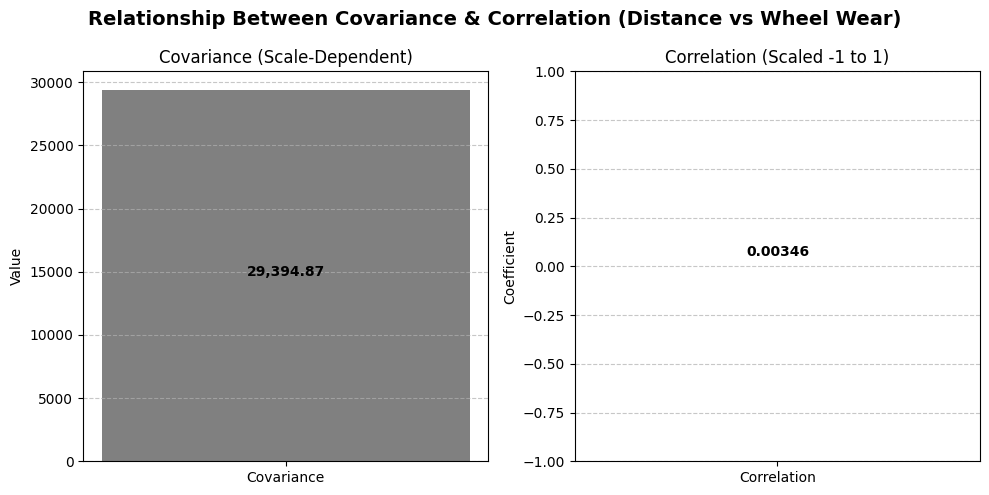

In [87]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Plot Covariance
axes[0].bar(["Covariance"], [cov_val], color="gray", width=0.4)
axes[0].set_title("Covariance (Scale-Dependent)")
axes[0].set_ylabel("Value")
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
for i, v in enumerate([cov_val]):
    axes[0].text(i, v/2, f"{v:,.2f}", ha='center', fontweight='bold')

# Plot Correlation
axes[1].bar(["Correlation"], [corr_val], color="salmon", width=0.4)
axes[1].set_title("Correlation (Scaled -1 to 1)")
axes[1].set_ylabel("Coefficient")
axes[1].set_ylim(-1, 1)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
for i, v in enumerate([corr_val]):
    axes[1].text(i, v + 0.05 if v >= 0 else v - 0.05, f"{v:.5f}", ha='center', fontweight='bold')

plt.suptitle("Relationship Between Covariance & Correlation (Distance vs Wheel Wear)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

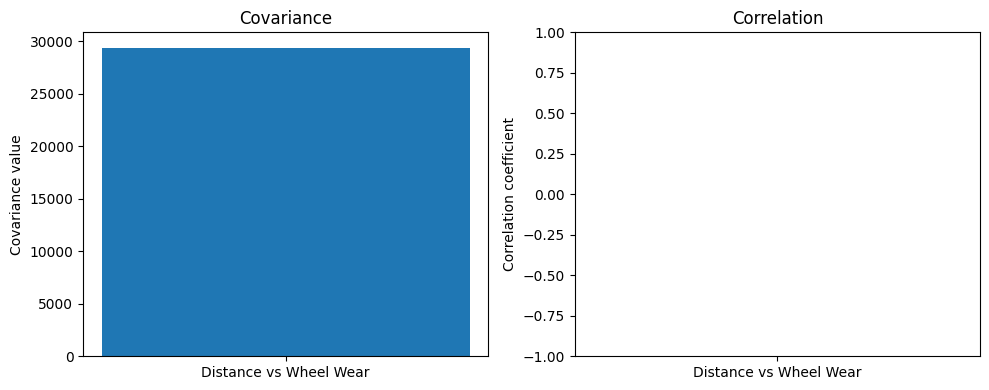

In [88]:
import matplotlib.pyplot as plt

# Create two plots
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(["Distance vs Wheel Wear"], [cov])
axes[0].set_title("Covariance")
axes[0].set_ylabel("Covariance value")

axes[1].bar(["Distance vs Wheel Wear"], [corr])
axes[1].set_title("Correlation")
axes[1].set_ylabel("Correlation coefficient")
axes[1].set_ylim(-1, 1)

plt.tight_layout()
plt.show()